In [ ]:
!pip install ripser

[1/6] t0=90.0s label_major=1 (Baseline) ratio=0.90
[2/6] t0=105.0s label_major=1 (Baseline) ratio=1.00
[3/6] t0=1590.0s label_major=3 (Amusement) ratio=0.80
[4/6] t0=2235.0s label_major=4 (Meditation) ratio=0.67
[5/6] t0=3195.0s label_major=2 (Stress) ratio=1.00
[6/6] t0=3210.0s label_major=2 (Stress) ratio=1.00
got: {1: 2, 2: 2, 3: 1, 4: 1}

TPV table shape: (6, 42)


,t_start_sec,label_major,label_bin
0,90.0,1,0
1,105.0,1,0
2,1590.0,3,0
3,2235.0,4,0
4,3195.0,2,1
5,3210.0,2,1


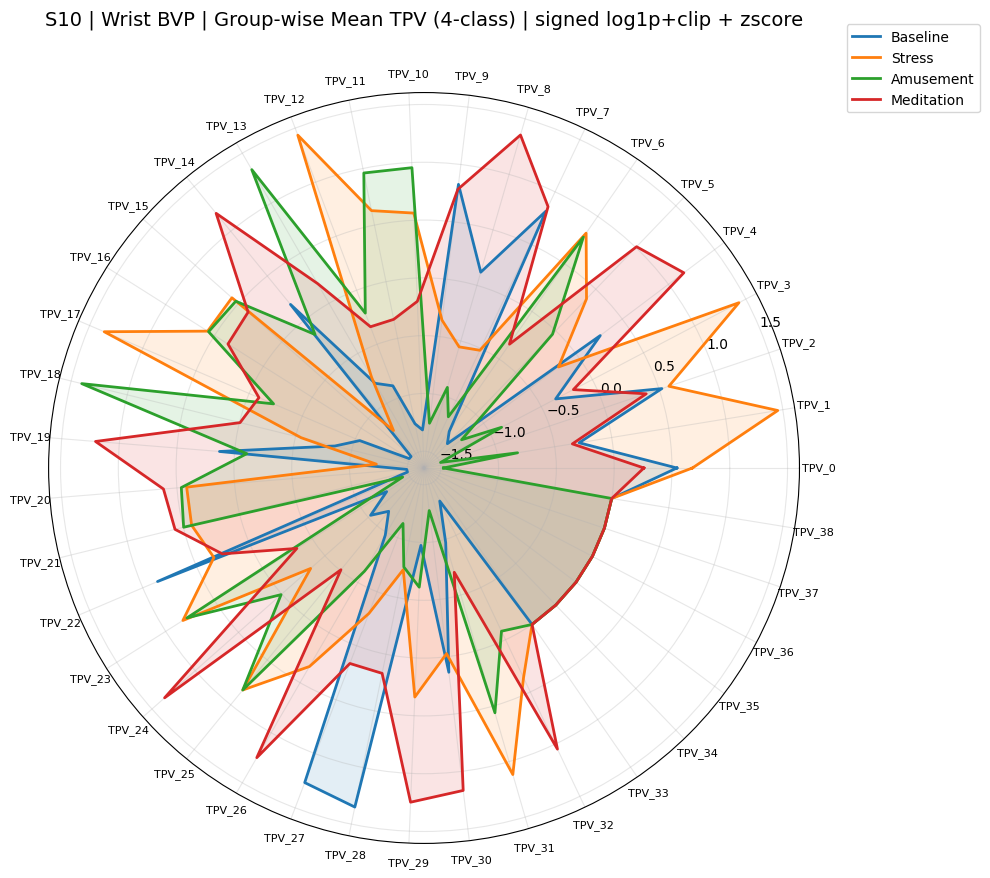

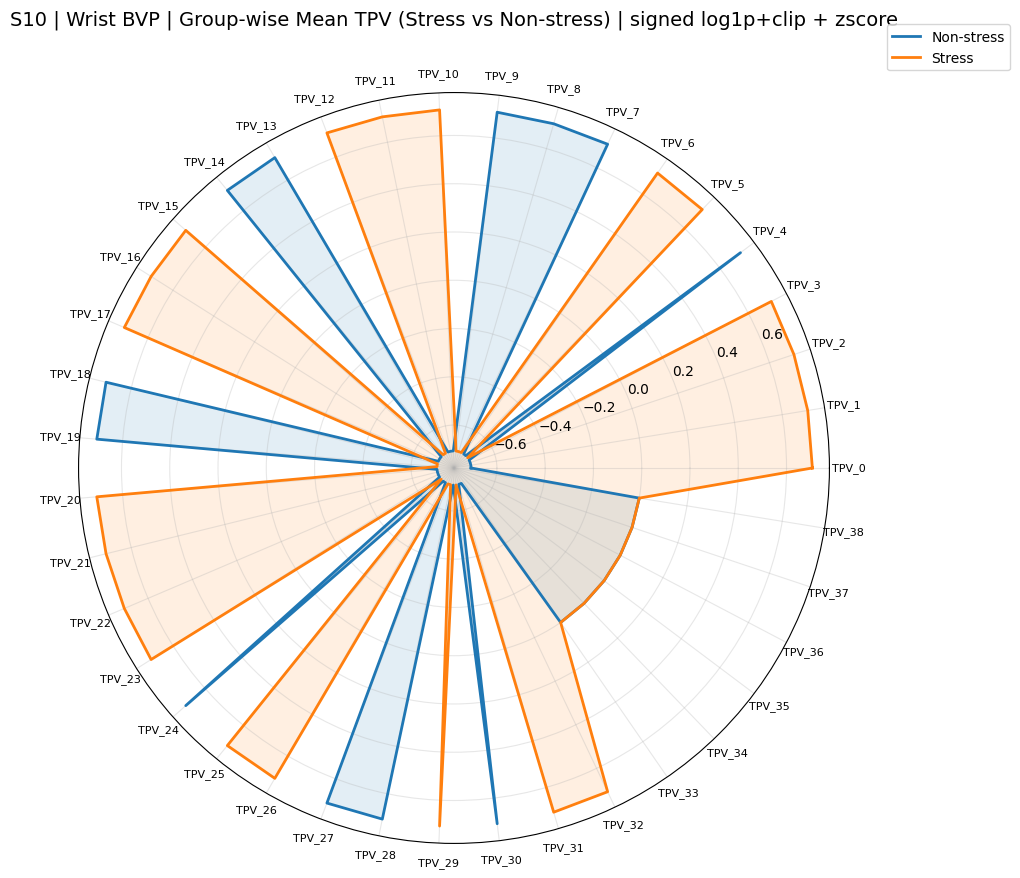

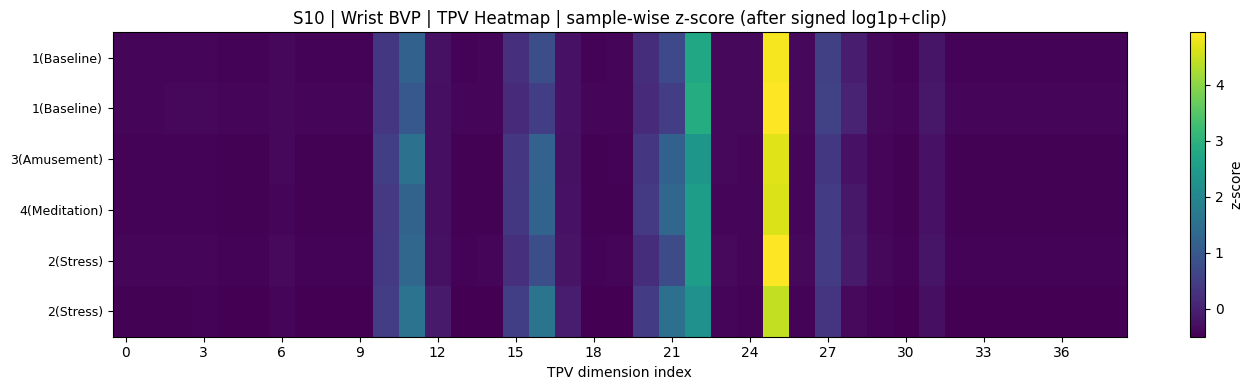

In [5]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ripser import ripser
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist

# =========================
# CONFIG
# =========================
pkl_path = "/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/S10.pkl"

FS_LABEL = 700
FS_BVP   = 64

WINDOW_SEC = 30
STEP_SEC   = 15

USE_LABELS   = {1, 2, 3, 4}
STRESS_ID    = 2
MAJ_RATIO_TH = 0.6

MAX_WIN = 6  # 단순 샘플링일 때 사용
TARGET_PER_LABEL = {1:2, 2:2, 3:1, 4:1}  # 균형 샘플링(총합=6). None이면 비활성

LABEL_NAME = {1:"Baseline", 2:"Stress", 3:"Amusement", 4:"Meditation"}

# =========================
# 1) TPV (39-d) from 1D signal
# =========================
def extract_tpv_39(sig_1d: np.ndarray) -> np.ndarray:
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)
    if len(sig) < 3:
        return np.zeros(39, dtype=np.float32)

    # window-wise z-score (shape 중심)
    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(39, dtype=np.float32)
    sig = (sig - float(np.mean(sig))) / (s + 1e-8)

    # delay embedding: (x_t, x_{t+1})
    X = np.stack([sig[:-1], sig[1:]], axis=1)

    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]
    if H1.size == 0:
        return np.zeros(39, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births, deaths, lifetimes = births[mask], deaths[mask], lifetimes[mask]
    if len(lifetimes) == 0:
        return np.zeros(39, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)

    feats = [
        float(np.mean(births)), float(np.std(births)),
        float(np.mean(deaths)), float(np.std(deaths)),
        float(np.mean(lifetimes)), float(np.std(lifetimes)),
        float(np.max(lifetimes)), float(np.min(lifetimes)),
        float(np.median(lifetimes)),
        float(iqr(lifetimes)),
        float(skew(lifetimes)) if len(lifetimes) > 2 else 0.0,
        float(kurtosis(lifetimes)) if len(lifetimes) > 3 else 0.0,

        float(np.max(births)), float(np.min(births)), float(np.median(births)),
        float(skew(births)) if len(births) > 2 else 0.0,
        float(kurtosis(births)) if len(births) > 3 else 0.0,

        float(np.max(deaths)), float(np.min(deaths)), float(np.median(deaths)),
        float(skew(deaths)) if len(deaths) > 2 else 0.0,
        float(kurtosis(deaths)) if len(deaths) > 3 else 0.0,

        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        float(np.sum(lifetimes ** 2)),
    ]

    lifetime_sum = float(np.sum(lifetimes)) + 1e-8
    lifetime_ratio = lifetimes / lifetime_sum
    PH_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin, bmax = float(np.min(births)), float(np.max(births))
    if bmax - bmin < 1e-8:
        Betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        Betti_entropy = float(entropy(hist + 1e-10))

    persistent_image_energy = float(np.sum(lifetimes ** 2))
    avg_persistence_distance = float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (2*np.sum(np.arange(1, n+1)*lifetimes_sorted))/(n*np.sum(lifetimes_sorted)) - (n+1)/n
        Gini_index = float(gini)
    else:
        Gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))

    feats.extend([PH_entropy, Betti_entropy, persistent_image_energy,
                  avg_persistence_distance, Gini_index, lifetime_variance])

    feats = np.asarray(feats, dtype=np.float32)
    if feats.shape[0] < 39:
        feats = np.pad(feats, (0, 39 - feats.shape[0]), constant_values=0.0)
    elif feats.shape[0] > 39:
        feats = feats[:39]

    return feats


# =========================
# 2) Build TPV table (단순 MAX_WIN or 균형 TARGET_PER_LABEL)
# =========================
def build_bvp_tpv_table(
    pkl_path: str,
    window_sec: int,
    step_sec: int,
    fs_label: int = 700,
    fs_bvp: int = 64,
    use_labels: set = {1,2,3,4},
    stress_id: int = 2,
    maj_ratio_th: float = 0.6,
    max_win: int | None = 6,
    target_per_label: dict | None = None,
    verbose: bool = True,
) -> pd.DataFrame:

    with open(pkl_path, "rb") as f:
        s = pickle.load(f, encoding="latin1")

    bvp = np.asarray(s["signal"]["wrist"]["BVP"]).reshape(-1).astype(np.float32)
    labels = np.asarray(s["label"]).astype(np.int64)

    # wrist duration 기준으로 label 잘라 정렬
    dur_wrist = len(bvp) / fs_bvp
    labels = labels[: int(dur_wrist * fs_label)]

    Wl = int(window_sec * fs_label)
    Sl = int(step_sec   * fs_label)
    Wb = int(window_sec * fs_bvp)

    tpv_rows = []
    cnt = 0

    got = None
    if target_per_label is not None:
        got = {k: 0 for k in target_per_label}

    for start_l in range(0, len(labels) - Wl + 1, Sl):
        end_l = start_l + Wl
        win_lab = labels[start_l:end_l]

        maj = int(np.bincount(win_lab).argmax())
        maj_ratio = float((win_lab == maj).mean())

        # 라벨 필터
        if maj not in use_labels or maj_ratio < maj_ratio_th:
            continue

        # 균형 샘플링 조건
        if got is not None:
            if maj not in got:
                continue
            if got[maj] >= target_per_label[maj]:
                continue

        # BVP slice
        t0 = start_l / fs_label
        start_b = int(round(t0 * fs_bvp))
        end_b = start_b + Wb
        if end_b > len(bvp):
            break

        seg_bvp = bvp[start_b:end_b]
        tpv = extract_tpv_39(seg_bvp)

        row = {
            "t_start_sec": float(t0),
            "label_major": maj,
            "label_bin": 1 if maj == stress_id else 0,
        }
        row.update({f"BVP_TPV_{j}": float(tpv[j]) for j in range(39)})
        tpv_rows.append(row)

        cnt += 1
        if got is not None:
            got[maj] += 1

        if verbose:
            if got is None:
                print(f"[{cnt}/{max_win}] t0={t0:.1f}s label_major={maj} ratio={maj_ratio:.2f}")
            else:
                tot = sum(got.values())
                target_tot = sum(target_per_label.values())
                print(f"[{tot}/{target_tot}] t0={t0:.1f}s label_major={maj} ({LABEL_NAME.get(maj,'')}) ratio={maj_ratio:.2f}")

        # stopping
        if got is None and max_win is not None and cnt >= max_win:
            break
        if got is not None and sum(got.values()) >= sum(target_per_label.values()):
            break

    df = pd.DataFrame(tpv_rows)
    if verbose and got is not None:
        print("got:", got)
    return df


# =========================
# 3) Visualization (radar + heatmap)
# =========================
def visualize_tpv(df: pd.DataFrame, title_prefix="BVP TPV"):
    if df is None or len(df) == 0:
        print("[Skip] empty df")
        return

    tpv_cols = [f"BVP_TPV_{i}" for i in range(39)]
    X = df[tpv_cols].values

    # 시각화 안정화: signed log1p + clip
    X_vis = np.sign(X) * np.log1p(np.abs(X))
    lo, hi = np.percentile(X_vis, 1), np.percentile(X_vis, 99)
    X_vis = np.clip(X_vis, lo, hi)

    df_vis = df.copy()
    df_vis[tpv_cols] = X_vis

    def radar_group_mean(df_in, group_col, group_name_map, title):
        gmeans = df_in.groupby(group_col)[tpv_cols].mean()
        if len(gmeans) >= 2:
            mu = gmeans.mean(axis=0)
            sd = gmeans.std(axis=0).replace(0, 1e-8)
            gplot = (gmeans - mu) / sd
        else:
            gplot = gmeans

        N = len(tpv_cols)
        angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
        angles += angles[:1]

        fig = plt.figure(figsize=(10, 10))
        ax = plt.subplot(111, polar=True)
        ax.set_title(title, y=1.08, fontsize=14)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([c.replace("BVP_TPV_", "TPV_") for c in tpv_cols], fontsize=8)
        ax.grid(True, alpha=0.3)

        for g in gplot.index:
            vals = gplot.loc[g].values.tolist() + [gplot.loc[g].values.tolist()[0]]
            ax.plot(angles, vals, linewidth=2, label=group_name_map.get(g, str(g)))
            ax.fill(angles, vals, alpha=0.12)

        ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
        plt.tight_layout()
        plt.show()

    # (1) 4-class radar (있는 라벨만)
    radar_group_mean(
        df_vis[df_vis["label_major"].isin([1,2,3,4])],
        group_col="label_major",
        group_name_map=LABEL_NAME,
        title=f"{title_prefix} | Group-wise Mean TPV (4-class) | signed log1p+clip + zscore"
    )

    # (2) stress vs nonstress radar
    radar_group_mean(
        df_vis,
        group_col="label_bin",
        group_name_map={0:"Non-stress", 1:"Stress"},
        title=f"{title_prefix} | Group-wise Mean TPV (Stress vs Non-stress) | signed log1p+clip + zscore"
    )

    # (3) heatmap (sample-wise z)
    Xh = df_vis[tpv_cols].values
    Xh = (Xh - Xh.mean(axis=1, keepdims=True)) / (Xh.std(axis=1, keepdims=True) + 1e-8)

    plt.figure(figsize=(14, 4))
    plt.imshow(Xh, aspect="auto")
    plt.colorbar(label="z-score")
    plt.yticks(
        np.arange(len(df_vis)),
        [f"{int(r.label_major)}({LABEL_NAME.get(int(r.label_major),'')})" for r in df_vis.itertuples()],
        fontsize=9
    )
    plt.xticks(range(0, 39, 3), [str(i) for i in range(0, 39, 3)])
    plt.xlabel("TPV dimension index")
    plt.title(f"{title_prefix} | TPV Heatmap | sample-wise z-score (after signed log1p+clip)")
    plt.tight_layout()
    plt.show()


# =========================
# RUN
# =========================
# 1) 균형 샘플링(추천): TARGET_PER_LABEL 사용
df_bvp_tpv_6 = build_bvp_tpv_table(
    pkl_path=pkl_path,
    window_sec=WINDOW_SEC,
    step_sec=STEP_SEC,
    fs_label=FS_LABEL,
    fs_bvp=FS_BVP,
    use_labels=USE_LABELS,
    stress_id=STRESS_ID,
    maj_ratio_th=MAJ_RATIO_TH,
    max_win=MAX_WIN,
    target_per_label=TARGET_PER_LABEL,   # <- 균형샘플링 ON (None이면 단순 MAX_WIN)
    verbose=True
)

print("\nTPV table shape:", df_bvp_tpv_6.shape)
display(df_bvp_tpv_6[["t_start_sec","label_major","label_bin"]])

# 2) 시각화
visualize_tpv(df_bvp_tpv_6, title_prefix="S10 | Wrist BVP")

# BVP-TPV + ACC (senity check)

In [1]:
# ============================================================
# WESAD (single subject) sanity check
#  - Features: BVP-TPV (TPV_DIM) + ACC simple feats (6)
#  - Labels: 4-class (1~4) and binary (stress=2 vs others)
#  - Split: time-based (no overlap leakage recommended)
# ============================================================

import pickle
import numpy as np
import pandas as pd

from ripser import ripser
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix


# =========================
# CONFIG
# =========================
pkl_path = "/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/S10.pkl"

FS_LABEL = 700
FS_BVP   = 64
FS_ACC   = 32

WINDOW_SEC = 30
STEP_SEC   = 15

USE_LABELS   = {1, 2, 3, 4}
STRESS_ID    = 2
MAJ_RATIO_TH = 0.6

LABEL_NAME = {1:"Baseline", 2:"Stress", 3:"Amusement", 4:"Meditation"}

TPV_DIM = 15  # ✅ 여기만 바꾸면 TPV 차원 바뀜


# =========================
# TPV from 1D signal -> TPV_DIM
# (기본 통계들 앞쪽부터 TPV_DIM개만 사용)
# =========================
def extract_tpv(sig_1d: np.ndarray, tpv_dim: int = TPV_DIM) -> np.ndarray:
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)
    if len(sig) < 3:
        return np.zeros(tpv_dim, dtype=np.float32)

    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(tpv_dim, dtype=np.float32)

    # window-wise z-score (shape 위주)
    sig = (sig - float(np.mean(sig))) / (s + 1e-8)

    # delay embedding
    X = np.stack([sig[:-1], sig[1:]], axis=1)

    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]  # loops
    if H1.size == 0:
        return np.zeros(tpv_dim, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births, deaths, lifetimes = births[mask], deaths[mask], lifetimes[mask]
    if len(lifetimes) == 0:
        return np.zeros(tpv_dim, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)

    # --- full feature pool (39-ish) ---
    feats = [
        float(np.mean(births)), float(np.std(births)),
        float(np.mean(deaths)), float(np.std(deaths)),
        float(np.mean(lifetimes)), float(np.std(lifetimes)),
        float(np.max(lifetimes)), float(np.min(lifetimes)),
        float(np.median(lifetimes)),
        float(iqr(lifetimes)),
        float(skew(lifetimes)) if len(lifetimes) > 2 else 0.0,
        float(kurtosis(lifetimes)) if len(lifetimes) > 3 else 0.0,

        float(np.max(births)), float(np.min(births)), float(np.median(births)),
        float(skew(births)) if len(births) > 2 else 0.0,
        float(kurtosis(births)) if len(births) > 3 else 0.0,

        float(np.max(deaths)), float(np.min(deaths)), float(np.median(deaths)),
        float(skew(deaths)) if len(deaths) > 2 else 0.0,
        float(kurtosis(deaths)) if len(deaths) > 3 else 0.0,

        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        float(np.sum(lifetimes ** 2)),
    ]

    # (옵션) 추가 topo metrics도 계산은 해두되, tpv_dim으로 컷
    lifetime_sum = float(np.sum(lifetimes)) + 1e-8
    lifetime_ratio = lifetimes / lifetime_sum
    PH_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin, bmax = float(np.min(births)), float(np.max(births))
    if bmax - bmin < 1e-8:
        Betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        Betti_entropy = float(entropy(hist + 1e-10))

    persistent_image_energy = float(np.sum(lifetimes ** 2))
    avg_persistence_distance = float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (2*np.sum(np.arange(1, n+1)*lifetimes_sorted))/(n*np.sum(lifetimes_sorted)) - (n+1)/n
        Gini_index = float(gini)
    else:
        Gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))

    feats.extend([
        PH_entropy, Betti_entropy, persistent_image_energy,
        avg_persistence_distance, Gini_index, lifetime_variance
    ])

    feats = np.asarray(feats, dtype=np.float32)

    # ✅ 최종 차원 컷 (tpv_dim)
    if feats.shape[0] < tpv_dim:
        feats = np.pad(feats, (0, tpv_dim - feats.shape[0]), constant_values=0.0)
    else:
        feats = feats[:tpv_dim]

    return feats


# =========================
# ACC simple features (6-d)
# =========================
def extract_acc_feats(acc_xyz: np.ndarray) -> np.ndarray:
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    mag = np.linalg.norm(acc_xyz, axis=1)

    feats = [
        float(np.mean(mag)),
        float(np.std(mag)),
        float(iqr(mag)),
        float(np.mean(mag**2)),            # energy
        float(np.percentile(mag, 95)),
        float(np.max(mag) - np.min(mag)),  # range
    ]
    return np.asarray(feats, dtype=np.float32)


# =========================
# Load pkl
# =========================
with open(pkl_path, "rb") as f:
    s = pickle.load(f, encoding="latin1")

bvp = np.asarray(s["signal"]["wrist"]["BVP"]).reshape(-1).astype(np.float32)
acc = np.asarray(s["signal"]["wrist"]["ACC"]).astype(np.float32)     # (N,3)
labels = np.asarray(s["label"]).astype(np.int64)

# ✅ duration align: BVP vs ACC 중 짧은 쪽으로 맞춘 뒤 label도 자르기
dur_bvp = len(bvp) / FS_BVP
dur_acc = len(acc) / FS_ACC
dur_wrist = min(dur_bvp, dur_acc)
labels = labels[: int(dur_wrist * FS_LABEL)]


# =========================
# Windowing -> X, y
# =========================
Wl = int(WINDOW_SEC * FS_LABEL)
Sl = int(STEP_SEC   * FS_LABEL)
Wb = int(WINDOW_SEC * FS_BVP)
Wa = int(WINDOW_SEC * FS_ACC)

X_list, y_bin_list, y4_list, meta = [], [], [], []

for start_l in range(0, len(labels) - Wl + 1, Sl):
    end_l = start_l + Wl
    win_lab = labels[start_l:end_l]

    maj = int(np.bincount(win_lab).argmax())
    maj_ratio = float((win_lab == maj).mean())
    if maj not in USE_LABELS or maj_ratio < MAJ_RATIO_TH:
        continue

    t0 = start_l / FS_LABEL

    # BVP slice
    start_b = int(round(t0 * FS_BVP))
    end_b = start_b + Wb
    if end_b > len(bvp):
        break
    seg_bvp = bvp[start_b:end_b]

    # ACC slice
    start_a = int(round(t0 * FS_ACC))
    end_a = start_a + Wa
    if end_a > len(acc):
        break
    seg_acc = acc[start_a:end_a, :]

    tpv = extract_tpv(seg_bvp, TPV_DIM)      # (TPV_DIM,)
    accf = extract_acc_feats(seg_acc)        # (6,)
    feat = np.concatenate([tpv, accf], axis=0)

    X_list.append(feat)
    y4_list.append(maj)
    y_bin_list.append(1 if maj == STRESS_ID else 0)
    meta.append((t0, maj, maj_ratio))

X = np.vstack(X_list) if len(X_list) else np.zeros((0, TPV_DIM + 6), dtype=np.float32)
y_bin = np.asarray(y_bin_list, dtype=np.int64)
y4 = np.asarray(y4_list, dtype=np.int64)

print("X:", X.shape)
if len(y_bin):
    print("y_bin counts:", {0:int((y_bin==0).sum()), 1:int((y_bin==1).sum())})
if len(y4):
    u, c = np.unique(y4, return_counts=True)
    print("y4 counts:", {int(k):int(v) for k,v in zip(u,c)})


# =========================
# Time-based split (sanity)
# =========================
if len(X) < 30:
    print("\n샘플이 너무 적음. WINDOW/STEP/TH 조정하거나 subject 늘려야 함.")
else:
    Xtr, Xte, ytr, yte = train_test_split(
        X,
        y_bin,
        test_size=0.3,
        random_state=42,
        stratify=y_bin
    )

    print("Train bin counts:", np.bincount(ytr))
    print("Test  bin counts:", np.bincount(yte))

    # 클래스 체크
    bc_tr = np.bincount(ytr, minlength=2)
    bc_te = np.bincount(yte, minlength=2)
    print("\nTrain bin counts:", {0:int(bc_tr[0]), 1:int(bc_tr[1])})
    print("Test  bin counts:", {0:int(bc_te[0]), 1:int(bc_te[1])})
    if bc_tr.min() < 3 or bc_te.min() < 2:
        print("⚠️ 한쪽 클래스가 너무 적어서 점수는 의미 없음(동작만 확인).")

    # =========================
    # Models
    # =========================
    models = {
        "LR": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ]),
        "RF": RandomForestClassifier(
            n_estimators=300, random_state=42, class_weight="balanced"
        ),
    }

    for name, mdl in models.items():
        mdl.fit(Xtr, ytr)
        pred = mdl.predict(Xte)

        f1 = f1_score(yte, pred, zero_division=0)
        accs = accuracy_score(yte, pred)
        print(f"\n[{name}] BIN Stress vs Non-stress | F1={f1:.3f} Acc={accs:.3f}")
        print(classification_report(yte, pred, digits=3, zero_division=0))

        cm = confusion_matrix(yte, pred, labels=[0,1])
        print("Confusion matrix [[TN FP],[FN TP]]:\n", cm)

DO_4CLASS = True
if DO_4CLASS and len(X) >= 40:
    order = np.argsort([m[0] for m in meta])
    Xo = X_list

X: (201, 21)
y_bin counts: {0: 154, 1: 47}
y4 counts: {1: 78, 2: 47, 3: 24, 4: 52}
Train bin counts: [107  33]
Test  bin counts: [47 14]

Train bin counts: {0: 107, 1: 33}
Test  bin counts: {0: 47, 1: 14}

[LR] BIN Stress vs Non-stress | F1=0.684 Acc=0.803
              precision    recall  f1-score   support

           0      0.973     0.766     0.857        47
           1      0.542     0.929     0.684        14

    accuracy                          0.803        61
   macro avg      0.757     0.847     0.771        61
weighted avg      0.874     0.803     0.817        61

Confusion matrix [[TN FP],[FN TP]]:
 [[36 11]
 [ 1 13]]

[RF] BIN Stress vs Non-stress | F1=0.846 Acc=0.934
              precision    recall  f1-score   support

           0      0.939     0.979     0.958        47
           1      0.917     0.786     0.846        14

    accuracy                          0.934        61
   macro avg      0.928     0.882     0.902        61
weighted avg      0.934     0.934   

# simple ablation study
- BVP
- ACC
- BVP + ACC

In [2]:
# ============================================================
# WESAD (single subject) sanity check - Ablation Logging
#  - Features: TPV-only / ACC-only / TPV+ACC
#  - Models  : LR / RF
#  - Tasks   : BIN (stress vs non-stress), 4-class (1~4)
#  - Output  : Macro-F1 only (clean logs)
# ============================================================

import pickle
import numpy as np

from ripser import ripser
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# =========================
# CONFIG
# =========================
pkl_path = "/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/S10.pkl"

FS_LABEL = 700
FS_BVP   = 64
FS_ACC   = 32

WINDOW_SEC = 30
STEP_SEC   = 15

USE_LABELS   = {1, 2, 3, 4}
STRESS_ID    = 2
MAJ_RATIO_TH = 0.6

LABEL_NAME = {1:"Baseline", 2:"Stress", 3:"Amusement", 4:"Meditation"}

TPV_DIM = 15   # 여기만 바꾸면 TPV 차원 바뀜
TEST_SIZE = 0.30
SEED = 42

DO_BIN = True
DO_4CLASS = True

# =========================
# TPV from 1D signal -> TPV_DIM
# (feature pool 앞쪽부터 TPV_DIM개 컷)
# =========================
def extract_tpv(sig_1d: np.ndarray, tpv_dim: int) -> np.ndarray:
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)
    if len(sig) < 3:
        return np.zeros(tpv_dim, dtype=np.float32)

    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(tpv_dim, dtype=np.float32)

    sig = (sig - float(np.mean(sig))) / (s + 1e-8)  # window z

    X = np.stack([sig[:-1], sig[1:]], axis=1)
    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]
    if H1.size == 0:
        return np.zeros(tpv_dim, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births, deaths, lifetimes = births[mask], deaths[mask], lifetimes[mask]
    if len(lifetimes) == 0:
        return np.zeros(tpv_dim, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)

    feats = [
        float(np.mean(births)), float(np.std(births)),
        float(np.mean(deaths)), float(np.std(deaths)),
        float(np.mean(lifetimes)), float(np.std(lifetimes)),
        float(np.max(lifetimes)), float(np.min(lifetimes)),
        float(np.median(lifetimes)),
        float(iqr(lifetimes)),
        float(skew(lifetimes)) if len(lifetimes) > 2 else 0.0,
        float(kurtosis(lifetimes)) if len(lifetimes) > 3 else 0.0,

        float(np.max(births)), float(np.min(births)), float(np.median(births)),
        float(skew(births)) if len(births) > 2 else 0.0,
        float(kurtosis(births)) if len(births) > 3 else 0.0,

        float(np.max(deaths)), float(np.min(deaths)), float(np.median(deaths)),
        float(skew(deaths)) if len(deaths) > 2 else 0.0,
        float(kurtosis(deaths)) if len(deaths) > 3 else 0.0,

        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        float(np.sum(lifetimes ** 2)),
    ]

    lifetime_sum = float(np.sum(lifetimes)) + 1e-8
    lifetime_ratio = lifetimes / lifetime_sum
    PH_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin, bmax = float(np.min(births)), float(np.max(births))
    if bmax - bmin < 1e-8:
        Betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        Betti_entropy = float(entropy(hist + 1e-10))

    persistent_image_energy = float(np.sum(lifetimes ** 2))
    avg_persistence_distance = float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (2*np.sum(np.arange(1, n+1)*lifetimes_sorted))/(n*np.sum(lifetimes_sorted)) - (n+1)/n
        Gini_index = float(gini)
    else:
        Gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))

    feats.extend([PH_entropy, Betti_entropy, persistent_image_energy,
                  avg_persistence_distance, Gini_index, lifetime_variance])

    feats = np.asarray(feats, dtype=np.float32)

    # tpv_dim으로 컷
    if feats.shape[0] < tpv_dim:
        feats = np.pad(feats, (0, tpv_dim - feats.shape[0]), constant_values=0.0)
    else:
        feats = feats[:tpv_dim]

    return feats

# =========================
# ACC simple features (6-d)
# =========================
def extract_acc_feats(acc_xyz: np.ndarray) -> np.ndarray:
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    mag = np.linalg.norm(acc_xyz, axis=1)
    feats = [
        float(np.mean(mag)),
        float(np.std(mag)),
        float(iqr(mag)),
        float(np.mean(mag**2)),            # energy
        float(np.percentile(mag, 95)),
        float(np.max(mag) - np.min(mag)),  # range
    ]
    return np.asarray(feats, dtype=np.float32)

# =========================
# Build dataset (X_tpv, X_acc, X_both), y_bin, y4
# =========================
with open(pkl_path, "rb") as f:
    s = pickle.load(f, encoding="latin1")

bvp = np.asarray(s["signal"]["wrist"]["BVP"]).reshape(-1).astype(np.float32)
acc = np.asarray(s["signal"]["wrist"]["ACC"]).astype(np.float32)
labels = np.asarray(s["label"]).astype(np.int64)

# align duration
dur_bvp = len(bvp) / FS_BVP
dur_acc = len(acc) / FS_ACC
dur_wrist = min(dur_bvp, dur_acc)
labels = labels[: int(dur_wrist * FS_LABEL)]

Wl = int(WINDOW_SEC * FS_LABEL)
Sl = int(STEP_SEC   * FS_LABEL)
Wb = int(WINDOW_SEC * FS_BVP)
Wa = int(WINDOW_SEC * FS_ACC)

X_tpv, X_acc, X_both = [], [], []
y_bin, y4 = [], []

for start_l in range(0, len(labels) - Wl + 1, Sl):
    end_l = start_l + Wl
    win_lab = labels[start_l:end_l]

    maj = int(np.bincount(win_lab).argmax())
    maj_ratio = float((win_lab == maj).mean())
    if maj not in USE_LABELS or maj_ratio < MAJ_RATIO_TH:
        continue

    t0 = start_l / FS_LABEL

    sb = int(round(t0 * FS_BVP)); eb = sb + Wb
    sa = int(round(t0 * FS_ACC)); ea = sa + Wa
    if eb > len(bvp) or ea > len(acc):
        break

    seg_bvp = bvp[sb:eb]
    seg_acc = acc[sa:ea, :]

    tpv = extract_tpv(seg_bvp, TPV_DIM)   # (TPV_DIM,)
    accf = extract_acc_feats(seg_acc)     # (6,)

    X_tpv.append(tpv)
    X_acc.append(accf)
    X_both.append(np.concatenate([tpv, accf], axis=0))

    y4.append(maj)
    y_bin.append(1 if maj == STRESS_ID else 0)

X_tpv  = np.vstack(X_tpv)  if len(X_tpv)  else np.zeros((0, TPV_DIM), dtype=np.float32)
X_acc  = np.vstack(X_acc)  if len(X_acc)  else np.zeros((0, 6), dtype=np.float32)
X_both = np.vstack(X_both) if len(X_both) else np.zeros((0, TPV_DIM+6), dtype=np.float32)

y_bin = np.asarray(y_bin, dtype=np.int64)
y4    = np.asarray(y4, dtype=np.int64)

print(f"Built windows: N={len(y_bin)} | TPV_DIM={TPV_DIM} | WINDOW={WINDOW_SEC}s STEP={STEP_SEC}s TH={MAJ_RATIO_TH}")
if len(y_bin):
    print("BIN counts:", {0:int((y_bin==0).sum()), 1:int((y_bin==1).sum())})
if len(y4):
    u,c = np.unique(y4, return_counts=True)
    print("4-class counts:", {int(k):int(v) for k,v in zip(u,c)})

# =========================
# Models
# =========================
def make_models():
    return {
        "LR": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ]),
        "RF": RandomForestClassifier(
            n_estimators=300, random_state=SEED, class_weight="balanced"
        )
    }

# =========================
# Evaluation helper (Macro-F1 only)
# =========================
def eval_macro_f1(model, Xtr, ytr, Xte, yte, average="macro"):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return f1_score(yte, pred, average=average, zero_division=0)

# =========================
# Split + Ablation logging
# =========================
if len(y_bin) < 40:
    print("⚠️ windows 너무 적음. (동작 확인만) WINDOW/STEP/TH 조정 or subject 늘리기 추천.")
else:
    # split indices once to ensure same split across ablations
    idx = np.arange(len(y_bin))
    idx_tr, idx_te = train_test_split(
        idx, test_size=TEST_SIZE, random_state=SEED, stratify=y_bin
    )

    # ablations
    feats_dict = {
        "TPV": X_tpv,
        "ACC": X_acc,
        "TPV+ACC": X_both
    }

    models = make_models()

    print("\n================= ABLATION RESULTS (Macro-F1) =================")
    print(f"Split: test_size={TEST_SIZE} stratify=y_bin seed={SEED}")
    print("--------------------------------------------------------------")
    header = f"{'Feat':<8} | {'Model':<3} | {'BIN_F1(macro)':>12} | {'4CLS_F1(macro)':>14}"
    print(header)
    print("-"*len(header))

    for feat_name, Xfeat in feats_dict.items():
        Xtr = Xfeat[idx_tr]
        Xte = Xfeat[idx_te]

        # labels
        ytr_bin, yte_bin = y_bin[idx_tr], y_bin[idx_te]
        ytr_4,   yte_4   = y4[idx_tr],    y4[idx_te]

        for mname, mdl in models.items():
            bin_f1 = np.nan
            f4_f1 = np.nan

            if DO_BIN:
                bin_f1 = eval_macro_f1(mdl, Xtr, ytr_bin, Xte, yte_bin, average="macro")

            if DO_4CLASS:
                # 4-class macro-f1도 동일 split로 (sanity)
                f4_f1 = eval_macro_f1(mdl, Xtr, ytr_4, Xte, yte_4, average="macro")

            print(f"{feat_name:<8} | {mname:<3} | {bin_f1:>12.3f} | {f4_f1:>14.3f}")

    print("===============================================================")

Built windows: N=201 | TPV_DIM=15 | WINDOW=30s STEP=15s TH=0.6
BIN counts: {0: 154, 1: 47}
4-class counts: {1: 78, 2: 47, 3: 24, 4: 52}

================= ABLATION RESULTS (Macro-F1) =================
Split: test_size=0.3 stratify=y_bin seed=42
--------------------------------------------------------------
Feat     | Model | BIN_F1(macro) | 4CLS_F1(macro)
-------------------------------------------------
TPV      | LR  |        0.573 |          0.539
TPV      | RF  |        0.705 |          0.631
ACC      | LR  |        0.740 |          0.562
ACC      | RF  |        0.834 |          0.761
TPV+ACC  | LR  |        0.771 |          0.690
TPV+ACC  | RF  |        0.902 |          0.837


# BVP-TPV + ACC + EDA

In [3]:
# ============================================================
# WESAD (single subject) sanity check
#  - Features: BVP-TPV (TPV_DIM) + ACC simple feats (6) + EDA simple feats (6)
#  - Labels: 4-class (1~4) and binary (stress=2 vs others)
#  - Split: stratified random split (sanity)  ※ time-based split은 별도로 권장
# ============================================================

import pickle
import numpy as np

from ripser import ripser
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix


# =========================
# CONFIG
# =========================
pkl_path = "/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/S10_E4_Data/S10.pkl"

FS_LABEL = 700
FS_BVP   = 64
FS_ACC   = 32
FS_EDA   = 4   # ✅ wrist EDA는 4Hz

WINDOW_SEC = 30
STEP_SEC   = 15

USE_LABELS   = {1, 2, 3, 4}
STRESS_ID    = 2
MAJ_RATIO_TH = 0.6

LABEL_NAME = {1:"Baseline", 2:"Stress", 3:"Amusement", 4:"Meditation"}

TPV_DIM = 15  # ✅ 여기만 바꾸면 TPV 차원 바뀜


# =========================
# TPV from 1D signal -> TPV_DIM
# (기본 통계들 앞쪽부터 TPV_DIM개만 사용)
# =========================
def extract_tpv(sig_1d: np.ndarray, tpv_dim: int = TPV_DIM) -> np.ndarray:
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)
    if len(sig) < 3:
        return np.zeros(tpv_dim, dtype=np.float32)

    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(tpv_dim, dtype=np.float32)

    sig = (sig - float(np.mean(sig))) / (s + 1e-8)  # window z-score

    X = np.stack([sig[:-1], sig[1:]], axis=1)
    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]
    if H1.size == 0:
        return np.zeros(tpv_dim, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births, deaths, lifetimes = births[mask], deaths[mask], lifetimes[mask]
    if len(lifetimes) == 0:
        return np.zeros(tpv_dim, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)

    feats = [
        float(np.mean(births)), float(np.std(births)),
        float(np.mean(deaths)), float(np.std(deaths)),
        float(np.mean(lifetimes)), float(np.std(lifetimes)),
        float(np.max(lifetimes)), float(np.min(lifetimes)),
        float(np.median(lifetimes)),
        float(iqr(lifetimes)),
        float(skew(lifetimes)) if len(lifetimes) > 2 else 0.0,
        float(kurtosis(lifetimes)) if len(lifetimes) > 3 else 0.0,

        float(np.max(births)), float(np.min(births)), float(np.median(births)),
        float(skew(births)) if len(births) > 2 else 0.0,
        float(kurtosis(births)) if len(births) > 3 else 0.0,

        float(np.max(deaths)), float(np.min(deaths)), float(np.median(deaths)),
        float(skew(deaths)) if len(deaths) > 2 else 0.0,
        float(kurtosis(deaths)) if len(deaths) > 3 else 0.0,

        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        float(np.sum(lifetimes ** 2)),
    ]

    # (옵션) topo metrics도 붙여두되 최종 tpv_dim으로 컷
    lifetime_sum = float(np.sum(lifetimes)) + 1e-8
    lifetime_ratio = lifetimes / lifetime_sum
    PH_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin, bmax = float(np.min(births)), float(np.max(births))
    if bmax - bmin < 1e-8:
        Betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        Betti_entropy = float(entropy(hist + 1e-10))

    persistent_image_energy = float(np.sum(lifetimes ** 2))
    avg_persistence_distance = float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (2*np.sum(np.arange(1, n+1)*lifetimes_sorted))/(n*np.sum(lifetimes_sorted)) - (n+1)/n
        Gini_index = float(gini)
    else:
        Gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))

    feats.extend([PH_entropy, Betti_entropy, persistent_image_energy,
                  avg_persistence_distance, Gini_index, lifetime_variance])

    feats = np.asarray(feats, dtype=np.float32)

    # 최종 차원 컷
    if feats.shape[0] < tpv_dim:
        feats = np.pad(feats, (0, tpv_dim - feats.shape[0]), constant_values=0.0)
    else:
        feats = feats[:tpv_dim]

    return feats


# =========================
# ACC simple features (6-d)
# =========================
def extract_acc_feats(acc_xyz: np.ndarray) -> np.ndarray:
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    mag = np.linalg.norm(acc_xyz, axis=1)
    feats = [
        float(np.mean(mag)),
        float(np.std(mag)),
        float(iqr(mag)),
        float(np.mean(mag**2)),            # energy
        float(np.percentile(mag, 95)),
        float(np.max(mag) - np.min(mag)),  # range
    ]
    return np.asarray(feats, dtype=np.float32)


# =========================
# EDA simple features (6-d)
#  - EDA는 느린 신호라 복잡한 것보다 우선 안정적인 통계로 시작
# =========================
def extract_eda_feats(eda_1d: np.ndarray) -> np.ndarray:
    eda = np.asarray(eda_1d, dtype=np.float32).reshape(-1)
    if len(eda) == 0:
        return np.zeros(6, dtype=np.float32)

    # (선택) baseline drift가 큰 신호라 1차 차분 통계도 같이 넣는 게 도움되는 경우 많음
    d = np.diff(eda) if len(eda) > 1 else np.array([0.0], dtype=np.float32)

    feats = [
        float(np.mean(eda)),
        float(np.std(eda)),
        float(iqr(eda)),
        float(np.percentile(eda, 95) - np.percentile(eda, 5)),  # robust range
        float(np.mean(np.abs(d))),  # mean abs slope
        float(np.std(d)),           # slope variability
    ]
    return np.asarray(feats, dtype=np.float32)


# =========================
# Load pkl
# =========================
with open(pkl_path, "rb") as f:
    s = pickle.load(f, encoding="latin1")

bvp = np.asarray(s["signal"]["wrist"]["BVP"]).reshape(-1).astype(np.float32)
acc = np.asarray(s["signal"]["wrist"]["ACC"]).astype(np.float32)      # (N,3)
eda = np.asarray(s["signal"]["wrist"]["EDA"]).reshape(-1).astype(np.float32)
labels = np.asarray(s["label"]).astype(np.int64)

# ✅ duration align: BVP/ACC/EDA 중 짧은 duration으로 맞춘 뒤 label도 자르기
dur_bvp = len(bvp) / FS_BVP
dur_acc = len(acc) / FS_ACC
dur_eda = len(eda) / FS_EDA
dur_wrist = min(dur_bvp, dur_acc, dur_eda)

labels = labels[: int(dur_wrist * FS_LABEL)]


# =========================
# Windowing -> X, y
# =========================
Wl = int(WINDOW_SEC * FS_LABEL)
Sl = int(STEP_SEC   * FS_LABEL)
Wb = int(WINDOW_SEC * FS_BVP)
Wa = int(WINDOW_SEC * FS_ACC)
We = int(WINDOW_SEC * FS_EDA)

X_list, y_bin_list, y4_list, meta = [], [], [], []

for start_l in range(0, len(labels) - Wl + 1, Sl):
    end_l = start_l + Wl
    win_lab = labels[start_l:end_l]

    maj = int(np.bincount(win_lab).argmax())
    maj_ratio = float((win_lab == maj).mean())
    if maj not in USE_LABELS or maj_ratio < MAJ_RATIO_TH:
        continue

    t0 = start_l / FS_LABEL

    # BVP slice
    start_b = int(round(t0 * FS_BVP))
    end_b = start_b + Wb
    if end_b > len(bvp):
        break
    seg_bvp = bvp[start_b:end_b]

    # ACC slice
    start_a = int(round(t0 * FS_ACC))
    end_a = start_a + Wa
    if end_a > len(acc):
        break
    seg_acc = acc[start_a:end_a, :]

    # EDA slice
    start_e = int(round(t0 * FS_EDA))
    end_e = start_e + We
    if end_e > len(eda):
        break
    seg_eda = eda[start_e:end_e]

    tpv  = extract_tpv(seg_bvp, TPV_DIM)      # (TPV_DIM,)
    accf = extract_acc_feats(seg_acc)         # (6,)
    edaf = extract_eda_feats(seg_eda)         # (6,)

    feat = np.concatenate([tpv, accf, edaf], axis=0)  # ✅ TPV+ACC+EDA

    X_list.append(feat)
    y4_list.append(maj)
    y_bin_list.append(1 if maj == STRESS_ID else 0)
    meta.append((t0, maj, maj_ratio))

X = np.vstack(X_list) if len(X_list) else np.zeros((0, TPV_DIM + 12), dtype=np.float32)
y_bin = np.asarray(y_bin_list, dtype=np.int64)
y4 = np.asarray(y4_list, dtype=np.int64)

print("Built windows:", len(X), f"| TPV_DIM={TPV_DIM} | WINDOW={WINDOW_SEC}s STEP={STEP_SEC}s TH={MAJ_RATIO_TH}")
if len(y_bin):
    print("BIN counts:", {0:int((y_bin==0).sum()), 1:int((y_bin==1).sum())})
if len(y4):
    u, c = np.unique(y4, return_counts=True)
    print("4-class counts:", {int(k):int(v) for k,v in zip(u,c)})


# =========================
# Sanity split + evaluate
# =========================
if len(X) < 30:
    print("\n샘플이 너무 적음. WINDOW/STEP/TH 조정하거나 subject 늘려야 함.")
else:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y_bin,
        test_size=0.3,
        random_state=42,
        stratify=y_bin
    )

    models = {
        "LR": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ]),
        "RF": RandomForestClassifier(
            n_estimators=300, random_state=42, class_weight="balanced"
        ),
    }

    for name, mdl in models.items():
        mdl.fit(Xtr, ytr)
        pred = mdl.predict(Xte)

        f1 = f1_score(yte, pred, average="macro", zero_division=0)
        accs = accuracy_score(yte, pred)
        print(f"\n[{name}] BIN Stress vs Non-stress | Macro-F1={f1:.3f} Acc={accs:.3f}")
        print(classification_report(yte, pred, digits=3, zero_division=0))

        cm = confusion_matrix(yte, pred, labels=[0,1])
        print("Confusion matrix [[TN FP],[FN TP]]:\n", cm)

Built windows: 201 | TPV_DIM=15 | WINDOW=30s STEP=15s TH=0.6
BIN counts: {0: 154, 1: 47}
4-class counts: {1: 78, 2: 47, 3: 24, 4: 52}

[LR] BIN Stress vs Non-stress | Macro-F1=1.000 Acc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        47
           1      1.000     1.000     1.000        14

    accuracy                          1.000        61
   macro avg      1.000     1.000     1.000        61
weighted avg      1.000     1.000     1.000        61

Confusion matrix [[TN FP],[FN TP]]:
 [[47  0]
 [ 0 14]]

[RF] BIN Stress vs Non-stress | Macro-F1=0.929 Acc=0.951
              precision    recall  f1-score   support

           0      0.958     0.979     0.968        47
           1      0.923     0.857     0.889        14

    accuracy                          0.951        61
   macro avg      0.941     0.918     0.929        61
weighted avg      0.950     0.951     0.950        61

Confusion matrix [[TN FP],[FN TP]]:
 [[4